In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#load data 
filtered_rna = sc.read("../../BA_data/RNA/zf_multiome_atlas_full_RNA_v1_release.h5ad")
print(filtered_rna.shape)

gene_peaks_10kb = pd.read_csv("gene_peak_assignments_10kb.csv")
gene_peaks_10kb.shape

(94562, 32057)


(19380, 2)

## Processing

We exclude the genes that didn't have any known TSS, so we can compare the results also with the pearson r and OLS results.

In [3]:
#filtering out the genes not included in the gene-peak assignment file
genes_in_peaks = gene_peaks_10kb['gene_id'].unique()
filtered_rna = filtered_rna[:, filtered_rna.var_names.isin(genes_in_peaks)]
print(f"After filtering, {filtered_rna.n_vars} genes remain for SEACells fitting")

filtered_rna.shape

After filtering, 19380 genes remain for SEACells fitting


(94562, 19380)

In [ ]:
#copy the counts to ".raw" attribute of the anndata since it is necessary for downstream analysis
#this step is performed after filtering the data
raw_filtered_rna = sc.AnnData(filtered_rna.layers['counts'].copy())
raw_filtered_rna.obs_names, raw_filtered_rna.var_names = filtered_rna.obs_names, filtered_rna.var_names
filtered_rna.X = raw_filtered_rna.X # to make sure any function using X by default works on raw counts
filtered_rna.raw = raw_filtered_rna # SEACells will use .raw for fitting, so we set it here


In [ ]:
#Normalize cells, log-transform, and identify highly variable genes
sc.pp.normalize_per_cell(filtered_rna)
sc.pp.log1p(filtered_rna)
sc.pp.highly_variable_genes(filtered_rna, n_top_genes=2000)

/tmp/ipykernel_2457758/3329948503.py:2: FutureWarning: Use `sc.pp.normalize_total` instead.
  sc.pp.normalize_per_cell(filtered_rna)


In [ ]:
#Compute principal components
sc.tl.pca(filtered_rna, n_comps=50, use_highly_variable=True)

/tmp/ipykernel_2457758/1508363990.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(filtered_rna, n_comps=50, use_highly_variable=True)


In [6]:
#compute umap for visualization
sc.pp.neighbors(filtered_rna, n_neighbors=15, n_pcs=20)
sc.tl.umap(filtered_rna)

In [7]:
filtered_rna

AnnData object with n_obs × n_vars = 94562 × 19380
    obs: 'developmental_stage', 'dataset', 'zebrafish_anatomy_ontology_class', 'zebrafish_anatomy_ontology_class_coarse', 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_nc', 'pct_counts_nc', 'n_counts'
    var: 'features', 'mt', 'nc', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dataset_colors', 'log1p', 'zebrafish_anatomy_ontology_class_coarse_colors', 'zebrafish_anatomy_ontology_class_colors', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_umap_atac', 'X_umap_joint', 'X_umap_rna', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

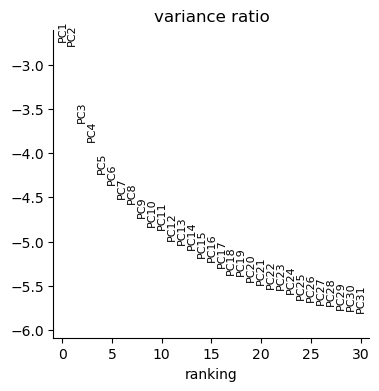

In [8]:
#plot elbow plot to determine the number of PCs to use for downstream analysis
sc.pl.pca_variance_ratio(filtered_rna, log=True)


## Running SEACells

As a rule of thumb, it is recommended choosing one metacell for every 75 single-cells.


In [ ]:
#computing number of metacells for every 75 single cells 
filtered_rna.n_obs / 75

1260.8266666666666

In [10]:
#SEACells is memory-bound on very large inputs, so fit on a reproducible subsample to avoid MemoryError
seacell_max_cells = filtered_rna.n_obs  # set to the number of cells in the dataset to use all cells for SEACells fit
if filtered_rna.n_obs > seacell_max_cells:
    rng = np.random.default_rng(0)
    seacell_ix = rng.choice(filtered_rna.n_obs, size=seacell_max_cells, replace=False)
    seacell_rna = filtered_rna[seacell_ix].copy()
    print(f"Subsampling {filtered_rna.n_obs} cells to {seacell_max_cells} for SEACells fit")
else:
    seacell_rna = filtered_rna.copy()
    print(f"Using all {seacell_rna.n_obs} cells for SEACells fit")

#core parameters
n_SEACells = filtered_rna.n_obs // 75
build_kernel_on = 'X_pca'

#additional parameters
n_waypoint_eigs = 10

Using all 94562 cells for SEACells fit


In [12]:
#convergence epsilon is set to a small value to ensure that the algorithm stops when the improvement in the fit becomes smaller than the specified threshold. This helps to prevent overfitting and ensures that the algorithm converges to a stable solution.

model = SEACells.core.SEACells(seacell_rna, 
                            build_kernel_on=build_kernel_on,
                            n_SEACells=n_SEACells, 
                            n_waypoint_eigs=n_waypoint_eigs, 
                            convergence_epsilon=1e-5,
                            use_gpu=False,
                            verbose=True)

Welcome to SEACells!


This analysis takes ~5 minutes.

In [13]:
model.construct_kernel_matrix()
M = model.kernel_matrix
print(M.shape)
print(type(M))

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/94562 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/94562 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/94562 [00:00<?, ?it/s]

Constructing CSR matrix...
(94562, 94562)
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
#sns.clustermap(M, cmap='viridis')
#sns.clustermap(M.toarray()[500:500])

In [14]:
# Initialize archetypes
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 


Done.
Sampling waypoints ...
Done.
Selecting 1235 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 35/35 [00:13<00:00,  2.62it/s]

Selecting 25 cells from greedy initialization.


In [15]:
%%time
# Fit the model to identify SEACells
model.fit(min_iter=1, max_iter= 5)
# save
model.save_model("../../SEACells/outputs")

Randomly initialized A matrix.
Setting convergence threshold at 0.00570
Starting iteration 1.
Completed iteration 1.
CPU times: user 6h 57min 9s, sys: 20min 16s, total: 7h 17min 25s
Wall time: 2h 17min 58s


RuntimeWarning: Warning: Algorithm has not converged - you may need to increase the maximum number of iterations

In [ ]:
#Plot the initialization to ensure they are spread across phenotypic space
SEACells.plot.plot_initialization(seacell_rna, model, plot_basis='X_pca')

In [ ]:
SEACells.plot.plot_initialization(seacell_rna, model, plot_basis='X_umap')

In [ ]:
# Save the object
seacell_rna.write("../../SEACells/outputs/zf_multiome_atlas_full_RNA_v1_SEACells.h5ad")

## Accessing results after running SEACells successfully

Load model results

In [ ]:
import pickle
with open("../../SEACells/outputs/model.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
# Check for convergence 
model.plot_convergence()

In [ ]:
#cells assigned to each SEACell
model.get_hard_assignments().head()

In [ ]:
#The majority of single-cells are assigned to no more than 4 SEACells, and the strength of the top 5 strongest assignments is generally high, suggesting that the SEACells are well-defined and distinct from each other.
plt.figure(figsize=(3,2))
sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)
plt.title(f'Non-trivial (> 0.1) assignments per cell')
plt.xlabel('# Non-trivial SEACell Assignments')
plt.ylabel('# Cells')
plt.show()

plt.figure(figsize=(3,2))
b = np.partition(model.A_.T, -5)    
sns.heatmap(np.sort(b[:,-5:])[:, ::-1], cmap='viridis', vmin=0)
plt.title('Strength of top 5 strongest assignments')
plt.xlabel('$n^{th}$ strongest assignment')
plt.show()

In [ ]:
labels,weights = model.get_soft_assignments()
labels.head()

SIngle cell object was updated with SEACell labels for each cell in the `.obs`

In [16]:
seacell_rna = sc.read_h5ad("../../SEACells/outputs/zf_multiome_atlas_full_RNA_v1_SEACells.h5ad")
seacell_rna.obs['SEACell']

index
AAACAGCCACCTAAGC-1_1     SEACell-701
AAACAGCCAGGGAGGA-1_1      SEACell-33
AAACAGCCATAGACCC-1_1    SEACell-1061
AAACATGCAAACTCAT-1_1     SEACell-102
AAACATGCAAGGACCA-1_1      SEACell-97
                            ...     
TTTGTGTTCCCTCAGT-1_7      SEACell-62
TTTGTTGGTACCTTAC-1_7    SEACell-1040
TTTGTTGGTATTGAGT-1_7     SEACell-874
TTTGTTGGTGCGCGTA-1_7     SEACell-267
TTTGTTGGTTAAGGCC-1_7     SEACell-324
Name: SEACell, Length: 94562, dtype: category
Categories (1260, object): ['SEACell-0', 'SEACell-1', 'SEACell-2', 'SEACell-3', ..., 'SEACell-1256', 'SEACell-1257', 'SEACell-1258', 'SEACell-1259']

/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


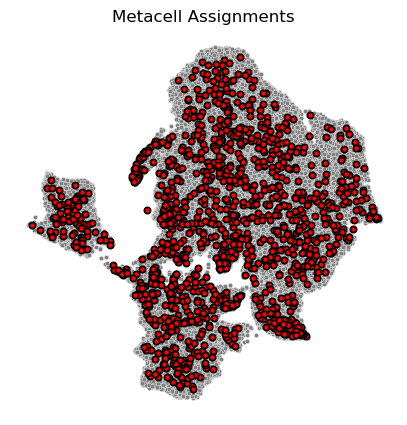

In [21]:
SEACells.plot.plot_2D(seacell_rna, key='X_umap', colour_metacells=False)

/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


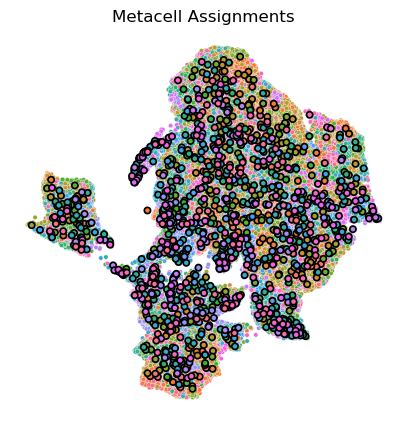

In [22]:
SEACells.plot.plot_2D(seacell_rna, key='X_umap', colour_metacells=True)

/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/SEACells/plot.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.distplot(label_df.groupby("SEACell").count().iloc[:, 0], bins=bins)
/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/SEACells/plot.py:130: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(label_df.groupby("SEACell").count().iloc[:, 0], bins=bins)


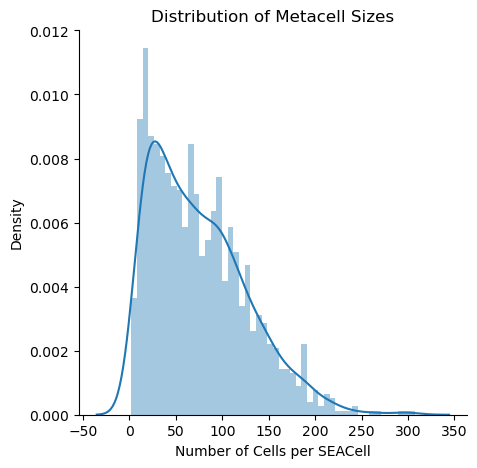

/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/SEACells/plot.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return pd.DataFrame(label_df.groupby("SEACell").count().iloc[:, 0]).rename(


,size
SEACell,
SEACell-0,116
SEACell-1,159
SEACell-2,55
SEACell-3,107
SEACell-4,133
...,...
SEACell-1255,111
SEACell-1256,99
SEACell-1257,91


In [23]:
SEACells.plot.plot_SEACell_sizes(seacell_rna, bins=50)

## Summarizing data

Datasets can be summarized by SEACell by aggregating cells within each SEACell, summing over all raw data for all cells belonging to a SEACell. The output of this function is an anndata object of shape n_metacells x original_data_dimension. Data is unnormalized and raw aggregated counts are stored in `X`. Attributes associated with variables (`.var`) are copied over, but relevant per SEACell attributes must be manually copied, since certain attributes may need to be summed, or averaged etc, depending on the attribute.

By default, `ad.raw` is used for summarization. Other layers present in the anndata can be specified using the parameter `summarize_layer`.

In [24]:
SEACell_ad = SEACells.core.summarize_by_SEACell(seacell_rna, SEACells_label='SEACell', summarize_layer='counts')
SEACell_ad

100%|██████████| 1260/1260 [00:03<00:00, 373.31it/s]
/sasselab3/home/elek/miniforge3/envs/seacells/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


AnnData object with n_obs × n_vars = 1260 × 19380
    layers: 'raw'

In [25]:
# Normalize and log-transform the summarized data for downstream analysis
sc.pp.normalize_total(SEACell_ad)
sc.pp.log1p(SEACell_ad)

In [ ]:
# UMAP
sc.pp.neighbors(SEACell_ad, n_neighbors=15, n_pcs=20)
sc.tl.umap(SEACell_ad)

In [ ]:
# Save summarized data
SEACell_ad.write("../../SEACells/SEACell_summarized_RNA.h5ad")